In [1]:
import os, glob, itertools, shutil, pydicom, warnings
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import scipy.stats as st
warnings.filterwarnings('ignore')

df_trust_patients = pd.read_csv(f"processed_data/combined_patient_WGS_data.csv")

df_PLI = pd.read_csv("~/TRUST_data_processing/processed_data/CXR_predictions.csv")

df_PLI_good = df_PLI.query("Status=='Normal' & Time=='BL' & View=='PA'").sort_values(['pid', 'predicted_PLI']).drop_duplicates('pid', keep='first')
len(df_PLI_good), len(df_PLI)

(417, 1466)

# Human Cavitation Reads

In [2]:
df_tbportals = pd.read_csv("~/TRUST_data_processing/raw_data/202060507_TRUST_wide_TBPortals_CXR.csv").rename(columns={'Patient identifier': 'pid', 'Imaging Study Date': 'img_study_date'})
df_tbportals['img_study_date'] = pd.to_datetime(df_tbportals['img_study_date'])
df_tbportals = df_tbportals.sort_values(['pid', 'img_study_date']).reset_index(drop=True)

# assign a binary variable for cavitation in each sextant if any value > 0
for sextant in ['LL', 'LR', 'ML', 'MR', 'UL', 'UR']:
    df_tbportals[f"cavities_{sextant}"] = (df_tbportals[df_tbportals.columns[df_tbportals.columns.str.contains(f'cavities_{sextant}')]].max(axis=1) > 0).astype(int)
    
# assign a binary variable for cavitation in the full image if any value > 0
df_tbportals['cavities_present'] = (df_tbportals[df_tbportals.columns[df_tbportals.columns.str.startswith('cavities_')]].max(axis=1) > 0).astype(int)

# can double check against Timika score - PLI. Difference = 40 if cavities present and 0 if absent
assert len(df_tbportals.loc[df_tbportals['timikascore'] == df_tbportals['overallpercentofabnormalvolume']].query("cavities_present==1")) == 0
assert len(df_tbportals.loc[df_tbportals['timikascore'] != df_tbportals['overallpercentofabnormalvolume']].query("cavities_present==0")) == 0

print(df_tbportals.groupby('pid')['imagingstudy_id'].count().unique())
df_tbportals['Image_Time'] = df_tbportals.groupby('pid')['imagingstudy_id'].cumcount().map({0: 'BL', 1: 'FU'})

df_tbportals.rename(columns={'overallpercentofabnormalvolume': 'human_PLI'}).to_csv("~/TRUST_data_processing/processed_data/20260507_TBPortals_data.csv", index=False)

[1 2]


In [27]:
df_bl = df_tbportals.query("Image_Time=='BL'").rename(columns={'overallpercentofabnormalvolume': 'human_PLI', 'cavities_present': 'Cavitation'})
assert df_bl.pid.nunique() == len(df_bl)

In [16]:
df_bl.cavities_present.mean()

0.6568848758465011

In [33]:
df_trust_patients.pid.nunique()

424

In [31]:
len(set(df_trust_patients.pid) - set(df_tbportals.pid))

14

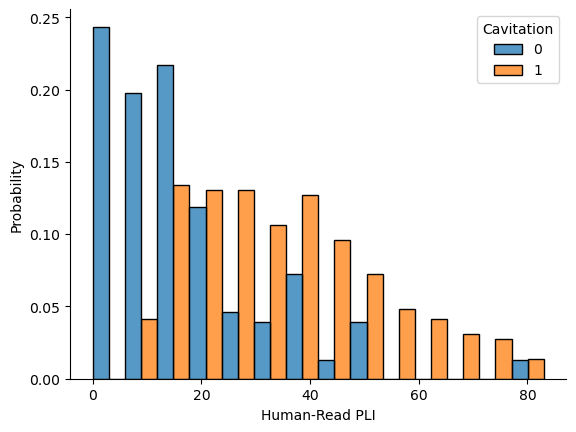

In [28]:
sns.histplot(data=df_bl,
             x='human_PLI',
             hue='Cavitation',
             common_norm=False,
             stat='probability',
             multiple='dodge'
            )

plt.xlabel('Human-Read PLI')
sns.despine()
plt.show()

In [38]:
np.mean(df_bl.query("Cavitation==1")['human_PLI']), np.mean(df_bl.query("Cavitation==0")['human_PLI']), np.mean(df_bl.query("Cavitation==1")['human_PLI']) - np.mean(df_bl.query("Cavitation==0")['human_PLI'])

(35.27147766323024, 16.68421052631579, 18.587267136914452)

In [39]:
np.median(df_bl.query("Cavitation==1")['human_PLI']), np.median(df_bl.query("Cavitation==0")['human_PLI'])

(32.0, 12.5)

In [34]:
df_bl['Cavitation'].value_counts()

Cavitation
1    291
0    152
Name: count, dtype: int64

In [36]:
df_bl.human_PLI.mean(), df_bl.human_PLI.median()

(28.89390519187359, 25.0)

# Human PLI Reads

In [3]:
df_human_PLI = pd.read_excel("~/TRUST_data_processing/raw_data/TRUST TB Portal Upload PLI.xlsx").sort_values(['pid', 'img_study_date']).reset_index(drop=True)
df_human_PLI.rename(columns={'percent_normal_value': 'human_PLI'}, inplace=True)

df_human_PLI['Image_Time'] = df_human_PLI.groupby('pid')['img_study_date'].cumcount().map({0: 'BL', 1: 'FU'})
# df_human_PLI.to_csv("~/TRUST_data_processing/processed_data/20260421_human_PLI_reads.csv", index=False)

In [43]:
df_human_PLI.merge(df_tbportals[['pid', 'img_study_date', 'overallpercentofabnormalvolume']], on=['pid', 'img_study_date']).query("human_PLI != overallpercentofabnormalvolume")

,pid,cxr_study_id,img_study_date,human_PLI,Image_Time,overallpercentofabnormalvolume


In [48]:
df_human_PLI.shape

(609, 5)

In [29]:
df_tbportals#.to_csv("~/TRUST_data_processing/processed_data/20260421_human_PLI_reads.csv", index=False)

,pid,managingorganization_id,imagingstudy_id,Imaging Study Date,othernontbabnormalities,aremediastinallymphnodespresent,timikascore,overallpercentofabnormalvolume,collapse_LL,collapse_ML,...,ispleuraleffusionbilateral_UR,ispleuraleffusionbilateral_LR,cavities_LL,cavities_LR,cavities_ML,cavities_MR,cavities_UL,cavities_UR,cavities_present,Image_Time
0,T0001,TRUST,6233227b-62c0-4cec-bc08-5a69a2712871,2017-01-02,no,no,27,27,0.0,0.0,...,no,NaN,0,0,0,0,0,0,0,BL
1,T0002,TRUST,1c089aae-c662-4e0c-8ed9-74fd26a50ea9,2017-01-01,no,no,56,16,NaN,NaN,...,no,NaN,0,0,0,0,0,1,1,BL
2,T0003,TRUST,f30d1ec7-4c2d-489f-9e4e-2a1898c849f1,2017-01-01,no,no,56,16,NaN,NaN,...,NaN,NaN,0,0,0,0,1,0,1,BL
3,T0005,TRUST,69d700c9-223b-43ad-a785-bda57de264d6,2017-01-01,no,no,56,16,NaN,NaN,...,no,NaN,0,0,0,0,0,1,1,BL
4,T0007,TRUST,4b4238df-1051-4b19-97dc-08d1a98522ec,2017-01-01,no,no,1,1,NaN,0.0,...,NaN,NaN,0,0,0,0,0,0,0,BL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,T0471,TRUST,484ec843-2ff5-4929-9095-7043aa06b567,2024-01-03,no,no,99,59,0.0,0.0,...,no,no,0,1,1,1,1,1,1,BL
605,T0472,TRUST,163bc151-fe37-42af-89f1-5e48dd4724b3,2024-01-01,no,no,107,67,0.0,0.0,...,no,no,0,1,1,1,1,1,1,BL
606,T0474,TRUST,3309468a-f036-4ea4-9183-99a9657cbefa,2023-12-29,no,no,84,44,0.0,0.0,...,no,no,0,0,1,1,1,1,1,BL
607,T0476,TRUST,6bf9b544-7480-4c64-9743-14eecb5f1f6a,2024-01-02,no,no,93,53,0.0,0.0,...,no,no,0,1,0,0,1,1,1,BL


In [169]:
# lateral (A) views are unusable.
df_combined = df_human_PLI.merge(df_PLI.query("View=='PA'"), on=['pid', 'Time'], how='outer')
len(df_combined)

692

In [191]:
pids_BL_human_reads = df_combined.dropna(subset='predicted_PLI').query("Time=='BL'").pid.nunique()
pids_BL_machine_reads = df_combined.dropna(subset='human_PLI').query("Time=='BL' & Status=='Normal'").pid.nunique()

print(f"{pids_BL_human_reads} pids have baseline human-read PLI")
print(f"{pids_BL_machine_reads} pids have baseline machine-read PLI")

449 pids have baseline human-read PLI
408 pids have baseline machine-read PLI


In [194]:
df_combined.dropna(subset='human_PLI').query("Time=='BL' & Status=='Normal'").view.value_counts()

view
1B        406
1B_new      3
1B_2        1
1D          1
1E          1
Name: count, dtype: int64

In [201]:
df_combined.dropna(subset='human_PLI').query("Time=='BL' & Status=='Normal'")

,pid,cxr_study_id,img_study_date,human_PLI,sample_idx,Time,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,view,View
0,T0001,6233227b-62c0-4cec-bc08-5a69a2712871,2017-01-02,27.0,0.0,BL,T0001_1B,23.755040,31.813820,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,1B,PA
1,T0002,1c089aae-c662-4e0c-8ed9-74fd26a50ea9,2017-01-01,16.0,0.0,BL,T0002_1B,27.663921,37.641080,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,1B,PA
2,T0003,f30d1ec7-4c2d-489f-9e4e-2a1898c849f1,2017-01-01,16.0,0.0,BL,T0003_1B,8.343956,13.879381,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,1B,PA
3,T0005,69d700c9-223b-43ad-a785-bda57de264d6,2017-01-01,16.0,0.0,BL,T0005_1B,19.653946,26.544138,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,1B,PA
4,T0007,4b4238df-1051-4b19-97dc-08d1a98522ec,2017-01-01,1.0,0.0,BL,T0007_1B,6.469509,9.153420,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,1B,PA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
614,T0470,989eeead-09e3-484f-b7b4-88098cf3d453,2024-01-02,24.0,0.0,BL,T0470_1B,21.430523,27.692919,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,1B,PA
615,T0471,484ec843-2ff5-4929-9095-7043aa06b567,2024-01-03,59.0,0.0,BL,T0471_1B,77.533170,94.181320,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,1B,PA
617,T0474,3309468a-f036-4ea4-9183-99a9657cbefa,2023-12-29,44.0,0.0,BL,T0474_1B,20.778086,25.877530,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,1B,PA
618,T0476,6bf9b544-7480-4c64-9743-14eecb5f1f6a,2024-01-02,53.0,0.0,BL,T0476_1B,40.826385,53.050304,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,1B,PA


In [198]:
df_PLI.query("View != 'LAT' & predicted_PLI > 100")

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,View
720,T0278_1C,104.621666,109.13715,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0278,1C,BL,AP
745,T0284_1C,110.200220,128.93106,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0284,1C,BL,AP
898,T0330_1C,125.272804,124.49140,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0330,1C,BL,AP
1143,T0393_1C,112.886500,134.20242,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0393,1C,BL,AP


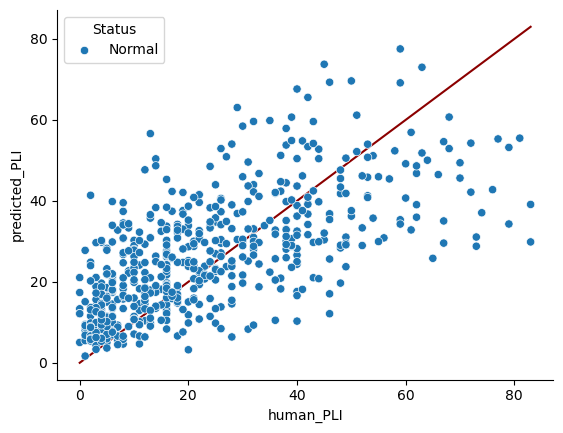

In [172]:
sns.scatterplot(data=df_combined.query("Status == 'Normal'"),
                x='human_PLI',
                y='predicted_PLI',
                hue='Status'
               )

x_vals = np.linspace(df_combined.query("Status == 'Normal'")['human_PLI'].min(), df_combined.query("Status == 'Normal'")['human_PLI'].max(), 100)
plt.plot(x_vals, x_vals, color='darkred', zorder=0)

sns.despine()
# plt.savefig("/home/sak0914/human_model_PLI_comparison.png", bbox_inches='tight', dpi=300)

In [175]:
st.spearmanr(df_combined.query("Status == 'Normal'").dropna(subset=['human_PLI', 'predicted_PLI'])['human_PLI'],
             df_combined.query("Status == 'Normal'").dropna(subset=['human_PLI', 'predicted_PLI'])['predicted_PLI']
            )

SignificanceResult(statistic=0.6871817614727929, pvalue=2.027520996507062e-81)

In [176]:
st.pearsonr(df_combined.query("Status == 'Normal'").dropna(subset=['human_PLI', 'predicted_PLI'])['human_PLI'],
             df_combined.query("Status == 'Normal'").dropna(subset=['human_PLI', 'predicted_PLI'])['predicted_PLI']
            )

PearsonRResult(statistic=0.660187527990646, pvalue=3.9975969625614006e-73)

In [179]:
st.spearmanr(df_combined.dropna(subset=['human_PLI', 'predicted_PLI'])['human_PLI'],
             df_combined.dropna(subset=['human_PLI', 'predicted_PLI'])['predicted_PLI']
            )

SignificanceResult(statistic=0.6792856801517199, pvalue=3.7203454303636446e-84)

In [180]:
st.pearsonr(df_combined.dropna(subset=['human_PLI', 'predicted_PLI'])['human_PLI'],
             df_combined.dropna(subset=['human_PLI', 'predicted_PLI'])['predicted_PLI']
            )

PearsonRResult(statistic=0.6422415569054732, pvalue=1.3733049637969481e-72)

# All the pids that got excluded if we keep only the good CXR predictions

In [16]:
pids_no_good_views = np.sort(list(set(df_trust_patients.pid) - set(df_PLI_good.pid)))
len(pids_no_good_views)

41

In [17]:
pids_no_CXR = np.sort(list(set(df_trust_patients.pid) - set(df_PLI.pid)))
len(pids_no_CXR)

7

In [34]:
not_PA_views = ['T0043_1B', 'T0134_1B', 'T0204_1B', 'T0264_1B']

df_combined.query("pid in @pids_no_good_views & patientID_view not in @not_PA_views")[['pid', 'human_PLI', 'Time', 'predicted_PLI', 'Status']].pid.nunique()

28

<Axes: xlabel='human_PLI', ylabel='predicted_PLI'>

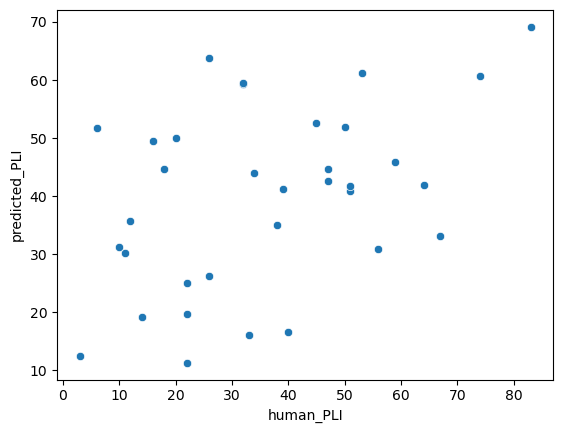

In [35]:
sns.scatterplot(data=df_combined.query("pid in @pids_no_good_views & patientID_view not in @not_PA_views"),
                x='human_PLI',
                y='predicted_PLI'
               )

# pids with multiple PA images at the same timepoint

In [181]:
multiple_views_per_pid_timepoint = pd.DataFrame(df_PLI.query("View=='PA' & Status=='Normal'").groupby(['pid', 'Time'])['patientID_view'].count()).query("patientID_view > 1").reset_index().pid.values
len(multiple_views_per_pid_timepoint)

9

In [182]:
pd.DataFrame(df_PLI.query("View=='PA' & Status=='Normal'").groupby(['pid', 'Time'])['patientID_view'].count()).query("patientID_view > 1")

,,patientID_view
pid,Time,
T0032,BL,2
T0101,BL,2
T0268,FU,2
T0292,FU,2
T0309,FU,2
T0362,FU,2
T0379,FU,2
T0403,BL,2
T0404,BL,2


In [183]:
df_multiples = df_combined.query("pid in @multiple_views_per_pid_timepoint & View=='PA' & Status=='Normal'").reset_index(drop=True)

df_multiples['predicted_PLI_range'] = df_multiples.groupby(['pid', 'Time'])['predicted_PLI'].transform(lambda x: max(x) - min(x))

In [184]:
df_multiples.query("predicted_PLI_range != 0")[['pid', 'Time', 'patientID_view', 'View', 'predicted_PLI', 'predicted_PLI_range', 'human_PLI']]

,pid,Time,patientID_view,View,predicted_PLI,predicted_PLI_range,human_PLI
0,T0032,BL,T0032_1B,PA,28.759197,1.267590,21.0
1,T0032,BL,T0032_1B_2,PA,30.026787,1.267590,21.0
2,T0101,BL,T0101_1D,PA,28.043283,5.040157,32.0
3,T0101,BL,T0101_1E,PA,33.083440,5.040157,32.0
5,T0268,FU,T0268_2B,PA,17.796305,0.223755,6.0
6,T0268,FU,T0268_2B_2,PA,18.020060,0.223755,6.0
15,T0403,BL,T0403_1B,PA,9.395120,0.008687,11.0
16,T0403,BL,T0403_1B_new,PA,9.403807,0.008687,11.0
18,T0404,BL,T0404_1B,PA,21.854815,0.305583,23.0
19,T0404,BL,T0404_1B_new,PA,21.549232,0.305583,23.0


In [185]:
df_PLI

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,View
0,T0001_1A,69.148780,76.412540,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0001,1A,BL,LAT
1,T0001_1B,23.755040,31.813820,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0001,1B,BL,PA
2,T0002_1A,88.009130,108.922720,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0002,1A,BL,LAT
3,T0002_1B,27.663921,37.641080,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0002,1B,BL,PA
4,T0003_1A,57.069702,74.677720,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0003,1A,BL,LAT
...,...,...,...,...,...,...,...,...,...
1461,T0476_1B,40.826385,53.050304,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0476,1B,BL,PA
1462,T0477_1A,94.598380,111.633286,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0477,1A,BL,LAT
1463,T0477_1B,38.594196,44.111030,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0477,1B,BL,PA
1464,T0477_2A,94.106100,113.017730,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0477,2A,FU,LAT


In [36]:
st.spearmanr(df_combined.query("pid in @pids_no_good_views & patientID_view not in @not_PA_views")['human_PLI'],
             df_combined.query("pid in @pids_no_good_views & patientID_view not in @not_PA_views")['predicted_PLI']
            )

SignificanceResult(statistic=0.35315707566586435, pvalue=0.040485418100188936)

In [6]:
pids_check = np.sort(list(set(pids_no_good_views) - set(pids_no_CXR) - set(['T0335', 'T0344', 'T0347'])))
len(pids_check)

31

In [39]:
pd.Series(pids_check).to_csv("~/pids_no_PLI_pred.txt", sep='\t', header=None, index=False)

In [11]:
outlier_PA_views = df_PLI.query("pid in @pids_check").query("Status=='Outlier' & Time=='BL' & view.str.contains('B')").Filename.values
len(outlier_PA_views)

31

In [22]:
set(pids_check) - set(df_PLI.query("pid in @pids_check").query("Status=='Outlier' & Time=='BL' & view.str.contains('B')").pid)

{'T0335', 'T0344', 'T0347'}

In [24]:
df_PLI.query("pid in ['T0335', 'T0344', 'T0347']").query("Status == 'Normal'")

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time
914,T0335_2B,9.748028,14.404529,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0335,2B,FU
915,T0335_2C,16.279114,19.830692,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0335,2C,FU
948,T0344_2B,9.123453,11.779844,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0344,2B,FU
958,T0347_2B,29.142101,29.781439,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0347,2B,FU


In [35]:
# for fName in df_PLI.query("pid in ['T0335', 'T0344', 'T0347']").query("Status == 'Normal'").Filename.values:
   
#     png_fName = fName.replace('.dcm', '.png').replace('dicom', 'png')
#     sample_name = os.path.basename(png_fName).split('.')[0]
    
#     # not PA views or some kind of truncation in the image
#     if sample_name not in ['T0033_1B', 'T0043_1B', 'T0134_1B', 'T0135_1B', 'T0204_1B', 'T0264_1B']:
    
#         img = mpimg.imread(png_fName)

#         plt.imshow(img, cmap='gray')
#         plt.title(f"{sample_name}")
#         plt.axis('off')
#         plt.show()
        
#         if not os.path.isfile(f"/home/sak0914/{sample_name}.png"):
#             shutil.copy(png_fName, f"/home/sak0914/{sample_name}.png")
#             print(f"/home/sak0914/{sample_name}.png")

In [20]:
df_PLI.query("pid in @pids_check").query("Time=='BL' & view.str.contains('B')").query("patientID_view not in @not_PA_views").predicted_PLI.min()

11.3101

In [24]:
df_PLI.query("pid in @pids_check").query("Time=='BL' & view.str.contains('B')").query("patientID_view not in @not_PA_views").predicted_PLI.median()



44.053432

<Axes: xlabel='predicted_PLI', ylabel='Count'>

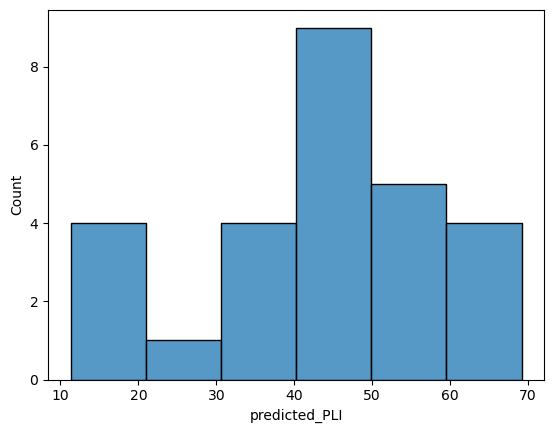

In [22]:
sns.histplot(data=df_PLI.query("pid in @pids_check").query("Time=='BL' & view.str.contains('B')").query("patientID_view not in @not_PA_views"),
             x='predicted_PLI'
            )

In [25]:
# df_PLI.query("pid in @pids_check").query("Status=='Outlier' & Time=='BL' & view.str.contains('B')")#.sort_values('predicted_PLI')


In [30]:
not_PA_views = ['T0043_1B', 'T0134_1B', 'T0204_1B', 'T0264_1B']

df_PLI.query("pid in @pids_check").query("Time=='BL' & view.str.contains('B')").query("patientID_view not in @not_PA_views")[['patientID_view', 'predicted_PLI', 'predicted_Timika']].to_csv("~/PLIs_to_check.csv", index=False)
                                                                                                                              
                                                                                                                              
                                                                                                                              

In [25]:
len(df_combined.query("Status=='Outlier'"))

127

In [29]:
df_PLI.query("patientID_view in @not_PA_views")

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time
76,T0043_1B,66.70980,92.44223,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0043,1B,BL
266,T0134_1B,57.49641,75.53288,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0134,1B,BL
471,T0204_1B,123.46229,142.96478,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0204,1B,BL
670,T0264_1B,100.92551,129.78992,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0264,1B,BL


In [31]:
df_combined.query("patientID_view in @not_PA_views")

,pid,cxr_study_id,img_study_date,human_PLI,sample_idx,Time,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,view,View
40,T0043,c23d5ea8-a9aa-47ad-a9fc-182a6c9d3d05,2018-01-06,26.0,0.0,BL,T0043_1B,66.70980,92.44223,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,1B,1B
146,T0134,d8d12016-1e35-48e0-9dfa-725435159e7c,2019-01-02,16.0,0.0,BL,T0134_1B,57.49641,75.53288,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,1B,1B
259,T0204,71cb9d9d-e1e7-49cc-923d-6d2ab2809025,2019-01-02,56.0,0.0,BL,T0204_1B,123.46229,142.96478,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,1B,1B
364,T0264,979a19bb-ed50-4809-aa96-dff9fa54f432,2022-05-26,4.0,0.0,BL,T0264_1B,100.92551,129.78992,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,1B,1B


# Fixing Mislabeled Views

In [61]:
# incorrect_views = {'T0043_1B': 'AP',
#                    'T0074_1C': 'LAT',
#                    'T0083_1C': 'PA',
#                    'T0101_1B': 'AP',
#                    'T0101_1C': 'LAT',
#                    'T0134_1B': 'AP',
#                    'T0175_1C': 'PA',
#                    'T0187_1C': 'PA',
#                    'T0227_2B': 'AP',
#                    'T0204_1B': 'LAT',
#                    'T0206_1C': 'LAT',
#                    'T0264_1B': 'LAT',
#                   }

# no_views = {'T0043_1D': 'PA',
#             'T0083_1D': 'AP',
#             'T0101_1D': 'PA',
#             'T0101_1E': 'PA',
#            }

In [62]:
# df_PLI['View'] = np.nan

# df_PLI.loc[df_PLI['view'].str.contains('A'), 'View'] = 'LAT'
# df_PLI.loc[df_PLI['view'].str.contains('B'), 'View'] = 'PA'
# df_PLI.loc[df_PLI['view'].str.contains('C'), 'View'] = 'AP'

In [63]:
# df_PLI.loc[pd.isnull(df_PLI['View'])]

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,View
78,T0043_1D,63.829056,80.602720,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0043,1D,BL,NaN
158,T0083_1D,24.626753,34.128822,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0083,1D,BL,NaN
192,T0101_1D,28.043283,34.083473,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0101,1D,BL,NaN
193,T0101_1E,33.083440,39.006794,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0101,1E,BL,NaN


In [64]:
# df_PLI.loc[pd.isnull(df_PLI['View']), 'View'] = df_PLI['patientID_view'].map(no_views)

In [65]:
# df_PLI.loc[pd.isnull(df_PLI['View'])]

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,View


In [71]:
# df_PLI.loc[df_PLI['patientID_view'].isin(incorrect_views.keys()), 'View'] = df_PLI['patientID_view'].map(incorrect_views)

In [95]:
# df_PLI.loc[df_PLI['patientID_view'].isin(incorrect_views.keys())]

In [117]:
# lateral (A) views are unusable. AP views aren't usable either, not sure why everyone is telling me they are
df_combined = df_human_PLI.merge(df_PLI.query("View != 'LAT'"), on=['pid', 'Time'], how='outer')

df_combined['human_machine_diff'] = df_combined['human_PLI'] - df_combined['predicted_PLI']
df_combined['human_machine_abs_diff'] = np.abs(df_combined['human_machine_diff'])

df_combined['human_machine_norm_diff'] = (df_combined['human_PLI'] - df_combined['predicted_PLI']) / df_combined['human_PLI']
df_combined['human_machine_abs_norm_diff'] = np.abs(df_combined['human_machine_norm_diff'])

# these are weird. Compare to the human reads
weird_PA_views = df_combined.query("Status=='Outlier' & View=='PA'").patientID_view.values
# weird_pids = 
len(weird_PA_views)

47

In [114]:
df_combined.query("pid=='T0010' & Time=='BL'")

,pid,cxr_study_id,img_study_date,human_PLI,sample_idx,Time,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,view,View,human_machine_diff,human_machine_abs_diff
7,T0010,f18361e8-83d0-4c74-aad1-4f111ece1387,2017-01-02,16.0,0.0,BL,T0010_1B,49.49146,60.183483,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,1B,PA,-33.49146,33.49146


In [115]:
for pid_view in weird_PA_views:
    if len(df_combined.query("patientID_view==@pid_view & Status=='Normal'")) > 0:
        print(pid_view)

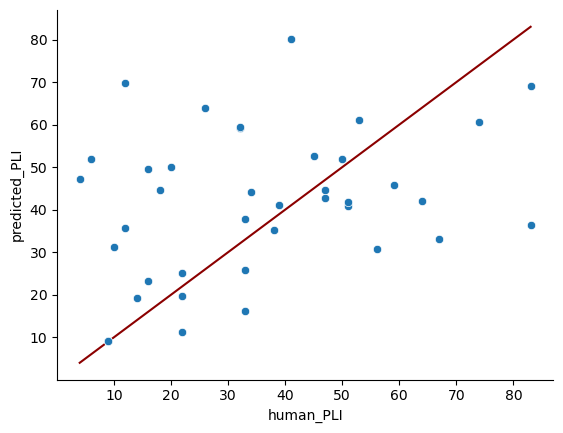

In [110]:
sns.scatterplot(data=df_combined.query("patientID_view in @weird_PA_views")[['pid', 'patientID_view', 'Time', 'human_PLI', 'predicted_PLI', 'View']],
                x='human_PLI',
                y='predicted_PLI'
               )

x_vals = np.linspace(df_combined.query("patientID_view in @weird_PA_views")['human_PLI'].min(), df_combined.query("patientID_view in @weird_PA_views")['human_PLI'].max(), 100)
plt.plot(x_vals, x_vals, color='darkred', zorder=0)

sns.despine()

In [120]:
df_combined.query("patientID_view=='T0010_1B'")

,pid,cxr_study_id,img_study_date,human_PLI,sample_idx,Time,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,view,View,human_machine_diff,human_machine_abs_diff,human_machine_norm_diff,human_machine_abs_norm_diff
7,T0010,f18361e8-83d0-4c74-aad1-4f111ece1387,2017-01-02,16.0,0.0,BL,T0010_1B,49.49146,60.183483,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,1B,PA,-33.49146,33.49146,-2.093216,2.093216


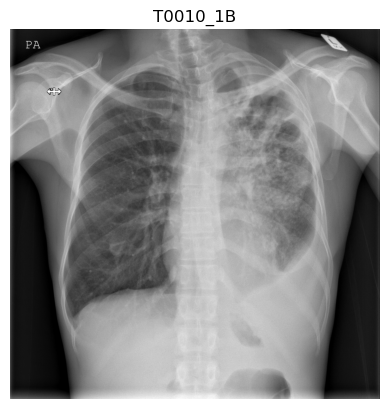

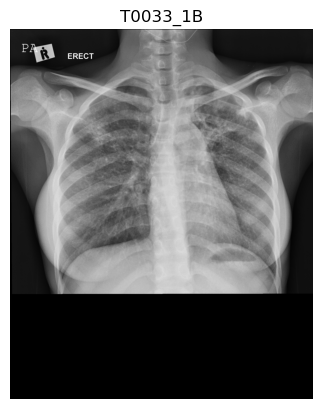

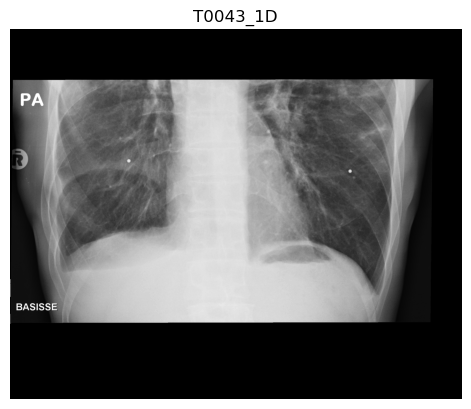

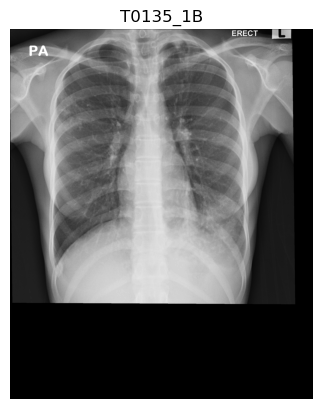

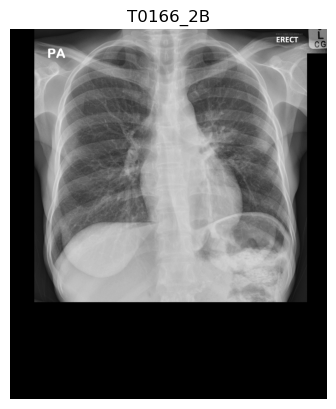

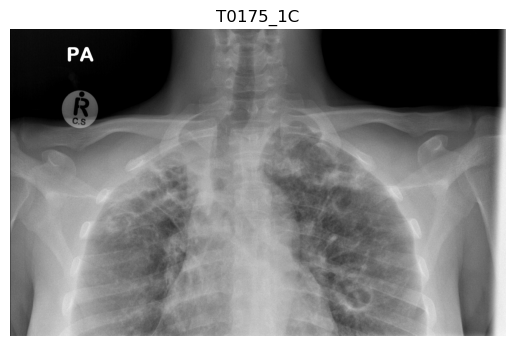

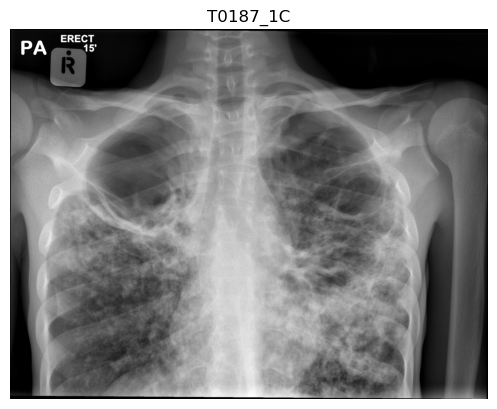

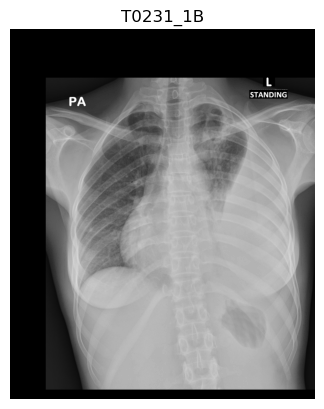

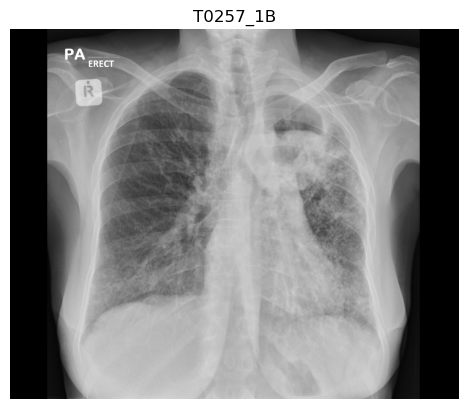

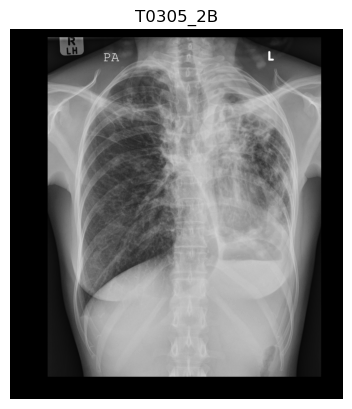

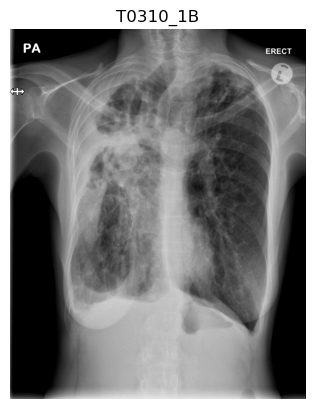

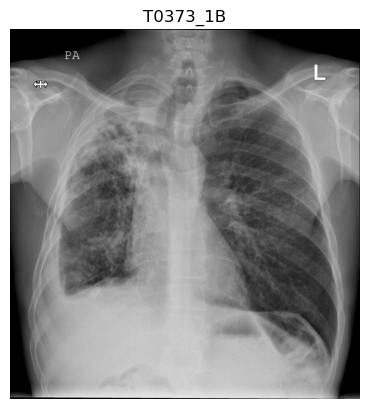

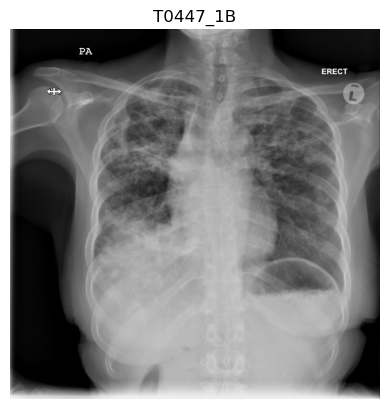

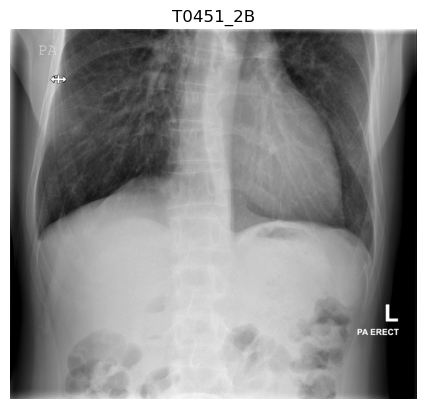

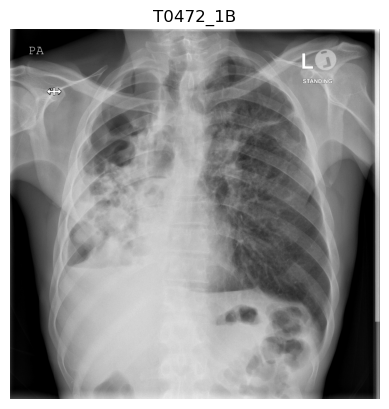

In [119]:
# for fName in outlier_PA_views:
# for fName in df_combined.query("predicted_PLI > 100").Filename.values:
# for fName in df_combined.query("Status=='Outlier'").Filename.values:
# for fName in df_combined.query("patientID_view in @incorrect_views").Filename.values:
# for fName in df_combined.query("patientID_view in ['T0083_1C', 'T0175_1C', 'T0187_1C']").Filename.values:
for fName in df_combined.query("patientID_view in @weird_PA_views & human_machine_abs_norm_diff > 0.5").Filename.values:
   
    png_fName = fName.replace('.dcm', '.png').replace('dicom', 'png')
    sample_name = os.path.basename(png_fName).split('.')[0]
    
    # not PA views or some kind of truncation in the image
    # if sample_name in ['T0033_1B', 'T0135_1B']:
    
    img = mpimg.imread(png_fName)

    plt.imshow(img, cmap='gray')
    plt.title(f"{sample_name}")
    plt.axis('off')
    plt.show()

#         if not os.path.isfile(f"/home/sak0914/{sample_name}.png"):
#             shutil.copy(png_fName, f"/home/sak0914/{sample_name}.png")
#             print(f"/home/sak0914/{sample_name}.png")

# Some pids have multiple Normal CXRs but way different model predictions

In [5]:
df_TRUST_tracking = pd.read_excel("raw_data/TRUST_CXR_Images_tracking.xlsx")
df_TRUST_tracking['Unique_Files'] = df_TRUST_tracking.groupby('Name')['Path'].transform(lambda x: len(np.unique(x)))
len(df_TRUST_tracking)

2011

In [3]:
df_TRUST_unique_files = pd.concat([df_TRUST_tracking.drop_duplicates(subset='Name', keep=False).query("Name.str.contains('_1')"),
                                   # df_TRUST_tracking.query("Unique_Files > 1").sort_values(['pid', 'Name', 'Path']).drop_duplicates(subset='Name', keep='first')
                                  ])
len(df_TRUST_unique_files)

956

In [4]:
df_TRUST_tracking.Unique_Files.value_counts()

Unique_Files
1.0    991
2.0    944
3.0     60
Name: count, dtype: int64

In [5]:
df_TRUST_unique_files.Unique_Files.value_counts()

Unique_Files
1.0    956
Name: count, dtype: int64

In [11]:
df_CXR_pred = pd.concat([pd.read_csv("processed_data/CXR_predictions.csv").query("Status=='Normal'").reset_index(drop=True),
                         # pd.read_csv("processed_data/TOTAL_CXR_predictions_baseline.csv").query("Status=='Normal'").reset_index(drop=True)
                        ])
# df_CXR_pred = pd.read_csv("~/TOTAL_CXR_pred.csv").query("Status=='Normal'").reset_index(drop=True)
df_CXR_pred['Name'] = df_CXR_pred['Filename'].apply(lambda x: os.path.basename(x))

# non-PA views. Some of the other letters might be PA
df_CXR_pred = df_CXR_pred.query("~view.str.contains('C') & ~view.str.contains('A')")

df_CXR_pred['predicted_PLI_diff'] = df_CXR_pred.groupby(['pid', 'Time'])['predicted_PLI'].transform(lambda x: np.max(x) - np.min(x))
df_CXR_pred['predicted_Timika_diff'] = df_CXR_pred.groupby(['pid', 'Time'])['predicted_Timika'].transform(lambda x: np.max(x) - np.min(x))

# df_CXR_pred = df_CXR_pred.query("view.str.contains('|'.join(['B', 'C'])) & Time=='BL'")

In [12]:
df_hehe = pd.read_csv("processed_data/CXR_predictions.csv")
len(df_hehe)

1466

In [13]:
# df_hehe.query("patientID_view!='T0025_1B_2'").to_csv("processed_data/CXR_predictions.csv", index=False)

In [15]:
df_CXR_pred.query("predicted_PLI_diff > 1").sort_values('predicted_PLI_diff', ascending=False)

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,Name,predicted_PLI_diff,predicted_Timika_diff
89,T0101_1D,28.043283,34.083473,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0101,1D,BL,T0101_1D.dcm,5.040157,4.923321
90,T0101_1E,33.083440,39.006794,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0101,1E,BL,T0101_1E.dcm,5.040157,4.923321
506,T0379_2B,18.563509,19.995907,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0379,2B,FU,T0379_2B.dcm,3.822121,7.928183
507,T0379_2B_2,22.385630,27.924090,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0379,2B_2,FU,T0379_2B_2.dcm,3.822121,7.928183
25,T0032_1B,28.759197,30.213636,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0032,1B,BL,T0032_1B.dcm,1.267590,3.636894
26,T0032_1B_2,30.026787,33.850530,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0032,1B_2,BL,T0032_1B_2.dcm,1.267590,3.636894


In [23]:
df_hehe.query("pid=='T0033'").Filename.values[-1]

'/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/dicom/T0033_1B.dcm'

In [26]:
df_hehe.query("pid=='T0033'")

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time
57,T0033_1A,187.85051,202.752380,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0033,1A,BL
58,T0033_1B,44.62714,55.285957,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Outlier,T0033,1B,BL


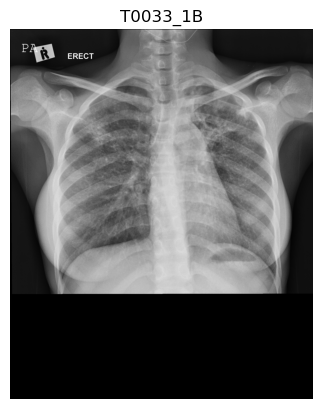

In [24]:
png_fName = '/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/png/T0033_1B.png'

img = mpimg.imread(png_fName)

plt.imshow(img, cmap='gray')
plt.title(f"{os.path.basename(png_fName).split('.')[0]}")
plt.axis('off')
plt.show()

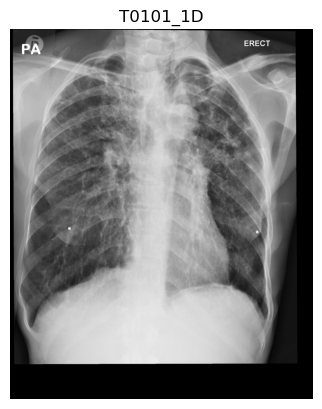

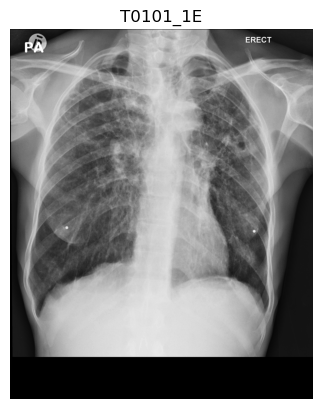

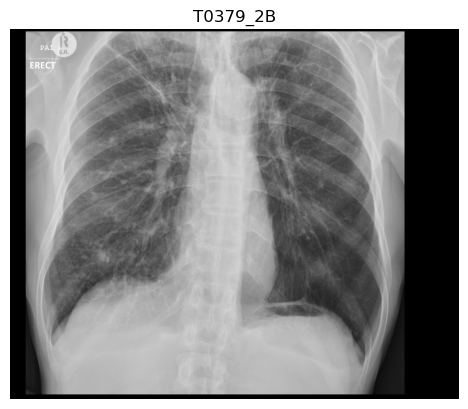

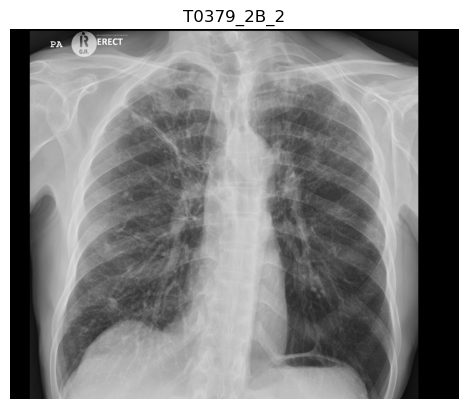

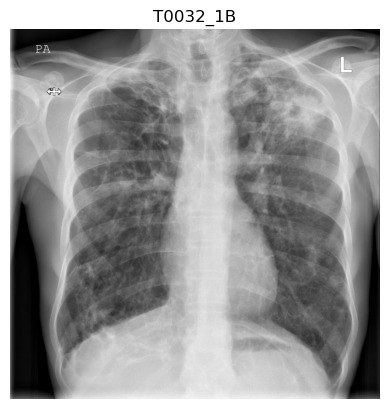

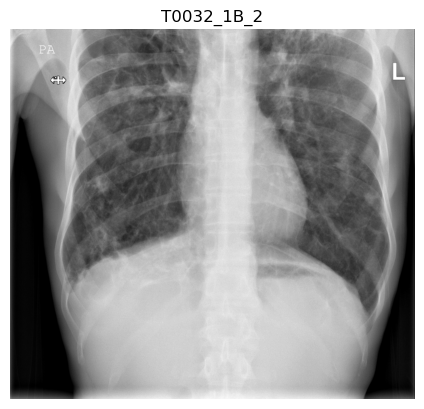

In [16]:
for i, row in df_CXR_pred.query("predicted_PLI_diff > 1").sort_values('predicted_PLI_diff', ascending=False).iterrows():
    
    dcm_fName = row['Filename']
    png_fName = dcm_fName.replace('dicom', 'png').replace('.dcm', '.png') #row['png_file']
    base_name = row['patientID_view']
    
    # needs additional plugins installed :(
#     ds = pydicom.dcmread(dcm_fName)

#     # Extract pixel data
#     img = ds.pixel_array
    
    img = mpimg.imread(png_fName)

    plt.imshow(img, cmap='gray')
    plt.title(f"{os.path.basename(png_fName).split('.')[0]}")
    plt.axis('off')
    plt.show()

In [8]:
df_annot = pd.read_csv("/n/data1/hms/dbmi/farhat/rs527/trust_project/annotations/Manual_CXR_reads_8-27-2024.csv")

pids_cav = df_annot[['pid', 'cxr_cavity_chest_radiograph_1']].query("cxr_cavity_chest_radiograph_1 == 'Yes'") #df_annot.query("cxr_cavity_chest_radiograph_1 == 'Yes'").pid.unique()
pids_no_cav = df_annot[['pid', 'cxr_cavity_chest_radiograph_1']].query("cxr_cavity_chest_radiograph_1 == 'No'") #df_annot.query("cxr_cavity_chest_radiograph_1 == 'No'").pid.unique()

pids_cav = df_annot.query("cxr_cavity_chest_radiograph_1 == 'Yes'").pid.unique()
pids_no_cav = df_annot.query("cxr_cavity_chest_radiograph_1 == 'No'").pid.unique()

# 1 = yes, 0 = no, 2 = unknown
# pids_cav = df_trust_patients.query("cxr_cavity_chest_radiograph_1==1").pid.unique()
# pids_no_cav = df_trust_patients.query("cxr_cavity_chest_radiograph_1==0").pid.unique()

len(pids_cav), len(pids_no_cav)

(283, 122)

In [9]:
df_trust_patients.dropna(subset='cxr_cavity_chest_radiograph_2')

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Kraken_Unclassified_Percent,Median_Depth,Perc_Sites_20x,Sampling_Week
79,T0386,S0386-01,MFS-884,MFS-884_lib84075,NaN,NaN,1.0,280.47,0.99,0.9002,...,0.250498,3.0,0.007664,4.1.1.1,4.1.i1.2.1,4.0,1.65,277.0,98.576776,1


In [10]:
# 1 = yes, 0 = no, 2 = unknown
df_trust_patients['bl_cxrcavity'].dropna().value_counts()

bl_cxrcavity
1.0    18
0.0    11
2.0     2
Name: count, dtype: int64

In [11]:
# df_cav = df_TRUST_unique_files.merge(pids_cav)[['pid', 'Name', 'cxr_cavity_chest_radiograph_1']].merge(df_CXR_pred[['Name', 'predicted_PLI', 'view', 'Time']])
# df_no_cav = df_TRUST_unique_files.merge(pids_no_cav)[['pid', 'Name', 'cxr_cavity_chest_radiograph_1']].merge(df_CXR_pred[['Name', 'predicted_PLI', 'view', 'Time']])

df_full = df_TRUST_unique_files.merge(df_CXR_pred[['Name', 'predicted_PLI', 'view', 'Time']])

len(df_full)

405

In [12]:
df_full['Category'] = pd.cut(df_full['predicted_PLI'], bins=[0, 20, 50, 70, 100], labels=[1, 2, 3, 4], right=True)

df_full.loc[df_full['pid'].isin(pids_cav), 'Cavitation'] = 1
df_full.loc[df_full['pid'].isin(pids_no_cav), 'Cavitation'] = 0

df_CXR_pred.loc[df_CXR_pred['pid'].isin(pids_cav), 'Cavitation'] = 1
df_CXR_pred.loc[df_CXR_pred['pid'].isin(pids_no_cav), 'Cavitation'] = 0

df_full.Category.value_counts()

Category
2    252
1    111
3     39
4      3
Name: count, dtype: int64

In [13]:
df_full[['Category', 'Cavitation']].value_counts(dropna=False)

Category  Cavitation
2         1.0           170
          0.0            57
1         0.0            56
          1.0            41
3         1.0            33
2         NaN            25
1         NaN            14
3         0.0             3
          NaN             3
4         1.0             2
          NaN             1
Name: count, dtype: int64

In [14]:
final_pids = list(df_full.query("Category==4").pid.unique()) + list(df_full.query("Category==3 & Cavitation==0").pid.unique()) + ['T0175', 'T0369'] + ['T0001', 'T0002', 'T0003', 'T0005', 'T0007', 'T0008', 'T0009', 'T0011', 'T0013', 'T0014', 'T0019', 'T0022']
final_pids = np.unique(final_pids)
len(final_pids)

20

In [40]:
df_full.query("pid in @final_pids").Cavitation.value_counts(dropna=False)

Cavitation
0.0    10
1.0     9
NaN     1
Name: count, dtype: int64

In [42]:
df_full.query("pid in @final_pids").Category.value_counts().sort_index()

Category
1    6
2    5
3    6
4    3
Name: count, dtype: int64

In [47]:
for fName in df_CXR_pred.query("patientID_view=='T0395_1B'").Filename.values:
    
    png_fName = f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/png/{os.path.basename(fName).split('.dcm')[0]}.png"
    
    shutil.copy(fName, f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/interrater_variability/{os.path.basename(fName)}")
    shutil.copy(png_fName, f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/interrater_variability/{os.path.basename(png_fName)}")

In [43]:
for fName in df_CXR_pred.query("pid in @final_pids").Filename.values:
    
    png_fName = f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/png/{os.path.basename(fName).split('.dcm')[0]}.png"
    
    shutil.copy(fName, f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/interrater_variability/{os.path.basename(fName)}")
    shutil.copy(png_fName, f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/interrater_variability/{os.path.basename(png_fName)}")

In [463]:
df_CXR_pred.query("predicted_PLI > 70")

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,Name,predicted_PLI_diff,predicted_Timika_diff,Cavitation
326,T0268_1B,73.749340,102.48273,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0268,1B,BL,T0268_1B.dcm,0.000000,0.000000,1.0
521,T0387_1B,73.005585,93.18298,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0387,1B,BL,T0387_1B.dcm,0.000000,0.000000,1.0
536,T0395_1B,93.135700,94.02654,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0395,1B,BL,T0395_1B.dcm,58.866142,55.746488,1.0
661,T0471_1B,77.533170,94.18132,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0471,1B,BL,T0471_1B.dcm,0.000000,0.000000,NaN


In [464]:
df_full.query("predicted_PLI > 70")

,pid,redcap_repeat_instance,Name,Modified,Modified By,Item Type,Path,redcap_event_name,redcap_repeat_instrument,cxr_dicom_add,notes,in_redcap,Unique_Files,predicted_PLI,view,Time,Category,Cavitation
236,T0268,1.0,T0268_1B.dcm,45379.489271,"Thomson, Sarah",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0,1.0,73.749340,1B,BL,"(70, 100]",1.0
333,T0387,1.0,T0387_1B.dcm,45449.409144,Rebecca E. Hoffman,Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0,1.0,73.005585,1B,BL,"(70, 100]",1.0
400,T0471,1.0,T0471_1B.dcm,45450.428877,Rebecca E. Hoffman,Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0,1.0,77.533170,1B,BL,"(70, 100]",NaN


In [339]:
df_full[['pid', 'Category']].sort_values('Category', ascending=False)

,pid,Category
331,T0387,"(70, 100]"
395,T0471,"(70, 100]"
234,T0268,"(70, 100]"
82,T0097,"(50, 70]"
272,T0311,"(50, 70]"
...,...,...
303,T0353,"(0, 20]"
74,T0088,"(0, 20]"
75,T0089,"(0, 20]"
224,T0255,"(0, 20]"


In [309]:
df_cav.Category.value_counts()

Category
(20, 50]     171
(0, 20]       46
(50, 70]      34
(70, 100]      2
Name: count, dtype: int64

In [299]:
# for name in df_cav.sort_values('Category').tail(7).Name.values:
    
#     fName = f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/png/{name.split('.dcm')[0]}.png"
#     assert os.path.isfile(fName)
    
#     shutil.copy(fName, f"/home/sak0914/{name.split('.dcm')[0]}.png")

In [300]:
df_no_cav.Category.value_counts()

Category
(20, 50]     58
(0, 20]      55
(50, 70]      3
(70, 100]     0
Name: count, dtype: int64

In [3]:
df_CXR_pred.query("predicted_PLI_diff > 0").pid.nunique(), df_CXR_pred.query("predicted_Timika_diff > 0").pid.nunique(), df_CXR_pred.query("predicted_PLI_diff > 0 | predicted_Timika_diff > 0").pid.nunique()

(37, 37, 37)

In [ ]:
n  PLI
5    0-20
5   21-50
5   51-70
5   71-100

n Hascavities
10  Y
10  N

In [5]:
df_CXR_pred

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,predicted_PLI_diff,predicted_Timika_diff
0,T0001_1B,23.755040,31.813820,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0001,1B,BL,0.0,0.0
1,T0002_1B,27.663921,37.641080,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0002,1B,BL,0.0,0.0
2,T0003_1B,8.343956,13.879381,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0003,1B,BL,0.0,0.0
3,T0005_1B,19.653946,26.544138,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0005,1B,BL,0.0,0.0
4,T0007_1B,6.469509,9.153420,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0007,1B,BL,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
667,T0475_1B,13.490097,19.729733,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0475,1B,BL,0.0,0.0
668,T0475_2B_2,12.451314,17.455038,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0475,2B_2,FU,0.0,0.0
669,T0476_1B,40.826385,53.050304,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0476,1B,BL,0.0,0.0
670,T0477_1B,38.594196,44.111030,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0477,1B,BL,0.0,0.0


In [4]:
df_CXR_pred.query("predicted_PLI_diff > 0")

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,predicted_PLI_diff,predicted_Timika_diff
19,T0025_1B,15.761469,25.813019,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0025,1B,BL,25.899347,25.653179
20,T0025_1B_2,41.660816,51.466198,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0025,1B_2,BL,25.899347,25.653179
26,T0032_1B,28.759197,30.213636,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0032,1B,BL,1.267590,3.636894
27,T0032_1B_2,30.026787,33.850530,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0032,1B_2,BL,1.267590,3.636894
48,T0057_1B,18.505900,27.716171,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0057,1B,BL,22.135225,23.774219
...,...,...,...,...,...,...,...,...,...,...
551,T0403_1B_new,9.403807,13.157445,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0403,1B_new,BL,0.008687,0.010799
553,T0404_1B,21.854815,26.095737,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0404,1B,BL,0.305583,0.235799
554,T0404_1B_new,21.549232,25.859938,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0404,1B_new,BL,0.305583,0.235799
662,T0471_2C_L,31.697674,38.984707,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0471,2C_L,FU,0.757676,2.159020


In [28]:
def compute_percent_black_pixels(png_fName, threshold=0):
    """
    Count the number of black pixels in a PNG image.

    Parameters
    ----------
    png_path : str or Path
        Path to the PNG file.
    threshold : int or float, optional
        Pixel intensity threshold for what counts as "black".
        For 8-bit images (0–255 range), lower values mean darker pixels.

    Returns
    -------
    int
        Number of black pixels.
    """
    # Read the image
    img = mpimg.imread(png_fName)
    
    # Convert to 0–255 if image is in float format (0–1)
    if img.dtype == np.float32 or img.dtype == np.float64:
        img = (img * 255).astype(np.uint8)
    
    # If RGB or RGBA, convert to grayscale intensity
    if img.ndim == 3:
        img = img[..., :3]  # drop alpha if present
        gray = np.mean(img, axis=2)
    else:
        gray = img  # already grayscale
        
    total_pixels = gray.shape[0]*gray.shape[1]
    
    prop_black = np.sum(gray <= threshold) / total_pixels

    return prop_black * 100

In [97]:
df_dicom_metadata = []

for pid in df_CXR_pred.pid.unique(): #df_CXR_pred.query("predicted_PLI_diff > 0").pid.unique():
    
    dicoms = df_CXR_pred.query("pid==@pid").Filename.values
    meta = []

    for d in dicoms:
        ds = pydicom.dcmread(d, stop_before_pixels=True)
        meta.append({
            "file": d,
            "SeriesInstanceUID": ds.get("SeriesInstanceUID", ""),
            "AcquisitionTime": ds.get("AcquisitionTime", ""),
            "InstanceNumber": ds.get("InstanceNumber", ""),
            "PixelSpacing": ds.get("PixelSpacing", ""),
            "ViewPosition": ds.get("ViewPosition", ""),
            "Rows": ds.get("Rows", ""),
            "Columns": ds.get("Columns", ""),
            "RescaleIntercept": ds.get("RescaleIntercept", ""),
            "RescaleSlope": ds.get("RescaleSlope", "")
        })

    df = pd.DataFrame(meta)
    df['BaseName'] = df['file'].apply(lambda x: os.path.basename(x))
    df['pid'] = pid
    
    df_dicom_metadata.append(df)
    
df_dicom_metadata = pd.concat(df_dicom_metadata).reset_index(drop=True)
len(df_dicom_metadata)

672

In [29]:
def extract_view_manually_from_dicom(dcm_path):
    """
    Search through all DICOM metadata for a substring "T CHEST"
    and return the entire string it appears in.
    
    Parameters
    ----------
    dcm_path : str
        Path to DICOM file.
    
    Returns
    -------
    str or None
        Full string containing "T CHEST", or None if not found.
    """
    ds = pydicom.dcmread(dcm_path, stop_before_pixels=True)

    for elem in ds:
        try:
            val = elem.value
            # Decode bytes to string if needed
            if isinstance(val, bytes):
                val = val.decode(errors="ignore")
            # If list/array, join as string
            elif isinstance(val, (list, tuple)):
                val = " ".join(str(v) for v in val)
            else:
                val = str(val)

            if "T CHEST" in val.upper():
                return val.split('CHEST ')[-1]  # return the whole string containing "T CHEST"
        except Exception:
            continue

    return None

In [99]:
for i, row in df_dicom_metadata.iterrows():
    
    if row['ViewPosition'] == '':
        view = extract_view_manually_from_dicom(row['file'])
        if view is not None:
            df_dicom_metadata.loc[i, 'ViewPosition'] = view
            
df_dicom_metadata['png_file'] = df_dicom_metadata['file'].str.replace('dicom', 'png').str.replace('.dcm', '.png')
df_dicom_metadata['ViewPosition'] = df_dicom_metadata['ViewPosition'].str.strip()
df_dicom_metadata.ViewPosition.value_counts()

ViewPosition
PA     414
       237
AP      17
LAT      4
Name: count, dtype: int64

In [100]:
def print_nonempty_dicom_fields(dcm_path):
    ds = pydicom.dcmread(dcm_path, stop_before_pixels=True)
    for elem in ds:
        if elem.VR != 'SQ' and elem.value not in [None, '', []]:
            print(f"{elem.keyword}: {elem.value}")
        elif elem.VR == 'SQ':  # handle sequences
            print(f"{elem.keyword}: (Sequence with {len(elem.value)} items)")

# Manual Changes

35 files don't have a view position that can be found with either of the above methods, and when using `print_nonempty_dicom_fields`, nothing obvious pops out, so I looked at them manually because there is a view within the pixels of each one.

In [101]:
df_CXR_pred.query("pid=='T0452'")

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,predicted_PLI_diff,predicted_Timika_diff
635,T0452_1B,3.214881,5.671096,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0452,1B,BL,0.0,0.0


In [102]:
# for the rest, I checked that A = LAT, B = PA, and C = AP
df_dicom_metadata.loc[(df_dicom_metadata['ViewPosition']=='') & (df_dicom_metadata['BaseName'].str.contains('A')), 'ViewPosition'] = 'LAT'
df_dicom_metadata.loc[(df_dicom_metadata['ViewPosition']=='') & (df_dicom_metadata['BaseName'].str.contains('B')), 'ViewPosition'] = 'PA'
df_dicom_metadata.loc[(df_dicom_metadata['ViewPosition']=='') & (df_dicom_metadata['BaseName'].str.contains('C')), 'ViewPosition'] = 'AP'

# these are wrong, where the letter does not correspond with the view
PA_samples = ['T0128_1C.dcm', 'T0137_1C.dcm']

AP_samples = ['T0395_1B.dcm']

# this one says LAT on the image, but it's def not LAT, so idk. It does look like PA
LAT_samples = ['T0452_1B.dcm']

df_dicom_metadata.loc[(df_dicom_metadata['BaseName'].isin(PA_samples)), 'ViewPosition'] = 'PA'
df_dicom_metadata.loc[(df_dicom_metadata['BaseName'].isin(AP_samples)), 'ViewPosition'] = 'AP'

assert len(df_dicom_metadata.query("ViewPosition==''")) == 0

In [130]:
df_dicom_metadata.query("BaseName.str.contains('|'.join(['E', 'D']))")

,file,SeriesInstanceUID,AcquisitionTime,InstanceNumber,PixelSpacing,ViewPosition,Rows,Columns,RescaleIntercept,RescaleSlope,BaseName,pid,png_file
90,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,1.2.276.0.7230010.3.1.4.2528215671.10392.16746...,,1,"[0.168, 0.168]",PA,2500,2048,0.0,1.0,T0101_1D.dcm,T0101,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...
91,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,1.2.276.0.7230010.3.1.4.2528215671.8924.167464...,,1,"[0.168, 0.168]",PA,2500,2048,0.0,1.0,T0101_1E.dcm,T0101,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...


In [134]:
for fName in df_dicom_metadata.query("pid=='T0101'").file.values:
    shutil.copy(fName, f"/home/sak0914/{os.path.basename(fName)}")

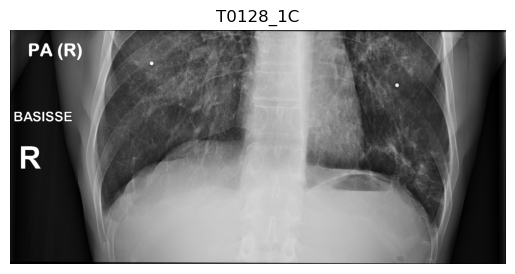

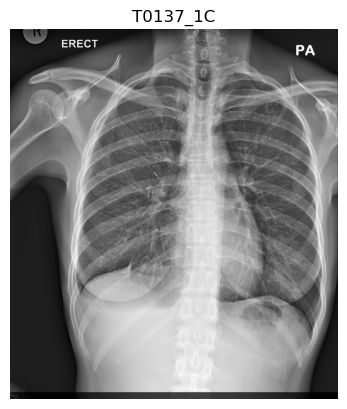

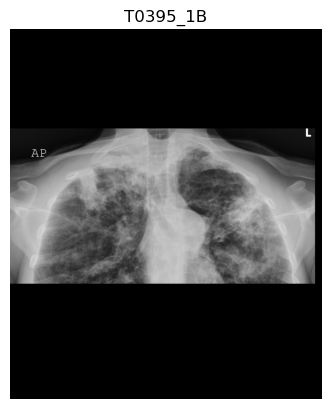

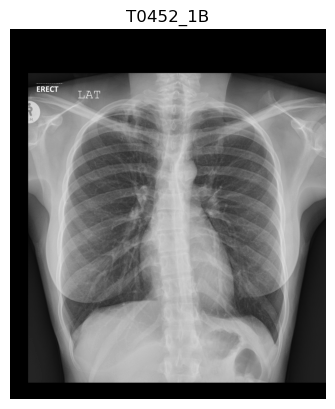

In [140]:
# for _, row in df_dicom_metadata.loc[(df_dicom_metadata['ViewPosition']=='') & (df_dicom_metadata['BaseName'].str.contains('B'))].iterrows():
# for _, row in df_dicom_metadata.query("BaseName.str.contains('|'.join(['2C_L', '2C_R']))").iterrows():
    
# for _, row in df_dicom_metadata.query("BaseName.str.contains('|'.join(['E', 'D']))").iterrows():
# for _, row in df_dicom_metadata.query("BaseName.str.contains('T0128')").iterrows():

for i, row in df_dicom_metadata.query("BaseName in @PA_samples | BaseName in @AP_samples | BaseName in @LAT_samples").iterrows():
    
    dcm_fName = row['file']
    png_fName = row['png_file']
    base_name = row['BaseName']
    
    # needs additional plugins installed :(
#     ds = pydicom.dcmread(dcm_fName)

#     # Extract pixel data
#     img = ds.pixel_array
    
    img = mpimg.imread(png_fName)

    plt.imshow(img, cmap='gray')
    plt.title(f"{os.path.basename(png_fName).split('.')[0]}")
    plt.axis('off')
    plt.show()

In [142]:
for fName in df_dicom_metadata.query("BaseName in @PA_samples | BaseName in @AP_samples | BaseName in @LAT_samples").png_file.values:
    shutil.copy(fName, f"/home/sak0914/{os.path.basename(fName)}")

In [103]:
df_dicom_metadata.ViewPosition.value_counts(dropna=False)

ViewPosition
PA     644
AP      24
LAT      4
Name: count, dtype: int64

In [104]:
df_CXR_pred = df_CXR_pred.merge(df_dicom_metadata[['file', 'ViewPosition']].rename(columns={'file': 'Filename'}), on='Filename')

In [110]:
df_CXR_pred['png_Filename'] = df_CXR_pred['Filename'].str.replace('.dcm', '.png').str.replace('dicom', 'png')
df_CXR_pred['Percent_Black_Pixels'] = df_CXR_pred['png_Filename'].apply(lambda x: compute_percent_black_pixels(x))
df_CXR_pred['Percent_Black_Pixels_diff'] = df_CXR_pred.groupby(['pid', 'Time'])['Percent_Black_Pixels'].transform(lambda x: np.max(x) - np.min(x))

In [111]:
# if you include other views, it only goes up to 420 pids, so this is fine
df_keep = df_CXR_pred.query("ViewPosition=='PA' & Time=='BL'").reset_index(drop=True)
df_keep.pid.nunique()

419

In [112]:
df_keep.iloc[df_keep.index.values[df_keep.duplicated(subset='pid', keep=False)]].sort_values('pid')

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,predicted_PLI_diff,predicted_Timika_diff,ViewPosition,png_Filename,Percent_Black_Pixels,Percent_Black_Pixels_diff
19,T0025_1B,15.761469,25.813019,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0025,1B,BL,25.899347,25.653179,PA,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,9.521719,21.622676
20,T0025_1B_2,41.660816,51.466198,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0025,1B_2,BL,25.899347,25.653179,PA,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,31.144395,21.622676
26,T0032_1B,28.759197,30.213636,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0032,1B,BL,1.267590,3.636894,PA,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,1.583238,2.272080
27,T0032_1B_2,30.026787,33.850530,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0032,1B_2,BL,1.267590,3.636894,PA,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,3.855318,2.272080
88,T0101_1D,28.043283,34.083473,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0101,1D,BL,5.040157,4.923321,PA,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,15.755879,3.912246
89,T0101_1E,33.083440,39.006794,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0101,1E,BL,5.040157,4.923321,PA,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,11.843633,3.912246
115,T0128_1B,41.911230,53.567192,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0128,1B,BL,0.182802,8.337572,PA,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,0.011554,0.323780
116,T0128_1C,42.094032,45.229620,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0128,1C,BL,0.182802,8.337572,PA,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,0.335334,0.323780
124,T0137_1B,14.044100,21.294900,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0137,1B,BL,0.632410,1.896247,PA,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,0.102814,0.043606
125,T0137_1C,14.676510,23.191147,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0137,1C,BL,0.632410,1.896247,PA,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,0.146420,0.043606


In [115]:
df_CXR_pred.view.unique()

array(['1B', '1B_2', '1C', '1D', '1E', '2B', '1A', '2A', '2B_2', '2C',
       '2B_new', '3B', '1B_new', '2C_L', '2C_R'], dtype=object)

In [14]:
def get_rows_columns_dicom_image(dcm_fName):
    
    # read in just the metadata. when you set stop_before_pixels = True, it doesn't read in the pixels
    ds = pydicom.dcmread(dcm_fName, stop_before_pixels=True)
    
    return ds.get("Rows", ""), ds.get("Columns", "")

In [15]:
df_CXR_pred[['nRows', 'nCols']] = df_CXR_pred['Filename'].apply(lambda x: pd.Series(get_rows_columns_dicom_image(x)))

# preferentially keep vertical CXRs
df_CXR_pred['Vertical'] = (df_CXR_pred['nRows'] > df_CXR_pred['nCols']).astype(int)

In [16]:
df_CXR_pred.query("predicted_PLI_diff > 10")

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,predicted_PLI_diff,predicted_Timika_diff,png_Filename,Percent_Black_Pixels,Percent_Black_Pixels_diff,nRows,nCols,Vertical
19,T0025_1B,15.761469,25.813019,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0025,1B,BL,25.899347,25.653179,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,9.521719,21.622676,2048,2500,0
20,T0025_1B_2,41.660816,51.466198,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0025,1B_2,BL,25.899347,25.653179,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,31.144395,21.622676,2048,2500,0
48,T0057_1B,18.505900,27.716171,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0057,1B,BL,22.135225,23.774219,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,3.629520,3.629520,2777,2238,1
49,T0057_1C,40.641125,51.490390,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0057,1C,BL,22.135225,23.774219,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,0.000000,3.629520,1427,2124,0
118,T0126_1B,30.627369,31.271664,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0126,1B,BL,15.581467,31.121822,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,7.123134,7.123134,2771,2764,1
119,T0126_1C,46.208836,62.393486,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0126,1C,BL,15.581467,31.121822,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,0.000000,7.123134,1923,2780,0
189,T0188_1B,22.712746,31.875923,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0188,1B,BL,14.201519,13.779607,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,10.970704,10.970704,2802,2528,1
190,T0188_1C,36.914265,45.655530,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0188,1C,BL,14.201519,13.779607,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,0.000000,10.970704,1639,2780,0
192,T0189_1B,13.162830,17.485382,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0189,1B,BL,11.355185,16.740891,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,10.684660,2.832813,2779,2606,1
193,T0189_1C,24.518015,34.226273,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0189,1C,BL,11.355185,16.740891,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,7.851847,2.832813,1315,2788,0


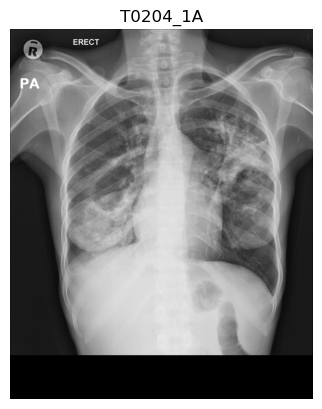

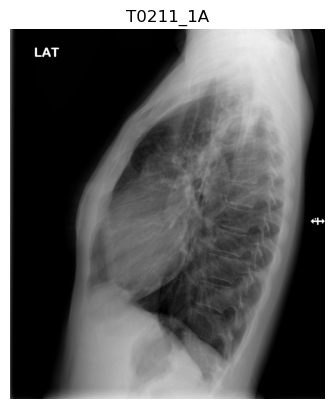

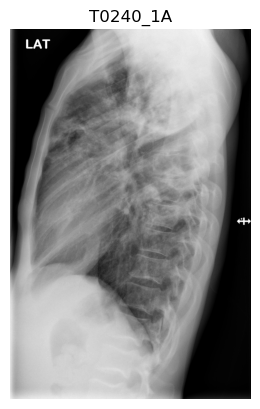

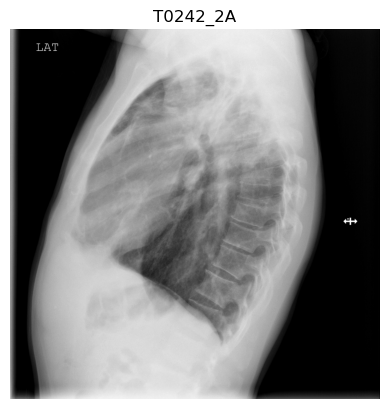

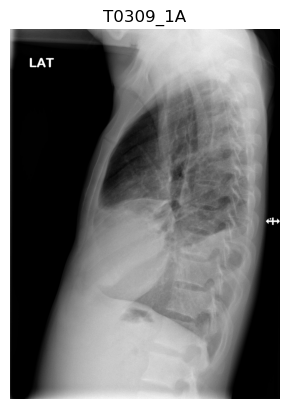

In [156]:
for png_fName in df_CXR_pred.query("view.str.contains('A')").png_Filename.values:
    img = mpimg.imread(png_fName)
    
    plt.imshow(img, cmap='gray')
    plt.title(f"{os.path.basename(png_fName).split('.')[0]}")
    plt.axis('off')
    plt.show()

In [ ]:
df_CXR_pred

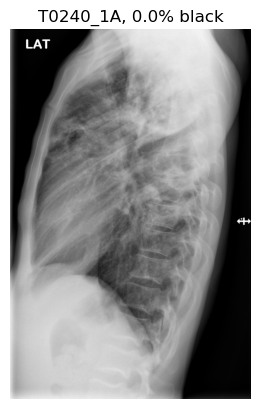

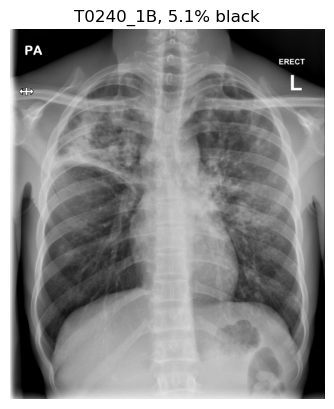

In [246]:
for i, row in df_CXR_pred.query("pid=='T0240'").iterrows():
    
    png_fName = row['png_Filename']
    perc_black = row['Percent_Black_Pixels']
    
    img = mpimg.imread(png_fName)
    
    plt.imshow(img, cmap='gray')
    plt.title(f"{os.path.basename(png_fName).split('.')[0]}, {np.round(perc_black, 1)}% black")
    plt.axis('off')
    plt.show()
    

In [157]:
df_check = pd.DataFrame({'fName1': ['/home/sak0914/Round_1/T0131_1A.dcm', '/home/sak0914/Round_1/T0131_1B.dcm'],
                         'fName2': ['/home/sak0914/Round_4/T0131_1A.dcm', '/home/sak0914/Round_4/T0131_1B.dcm']
                        })

In [159]:
# df_check.to_csv("~/dicom_check.csv", index=False)

In [160]:
pd.read_csv("~/dicom_check.csv")

,fName1,fName2,SameHeader,SamePixels
0,/home/sak0914/Round_1/T0131_1A.dcm,/home/sak0914/Round_4/T0131_1A.dcm,0.0,0.0
1,/home/sak0914/Round_1/T0131_1B.dcm,/home/sak0914/Round_4/T0131_1B.dcm,0.0,0.0


In [261]:
df_CXR_pred.query("pid=='T0057' & predicted_PLI_diff > 0")

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,predicted_PLI_diff,predicted_Timika_diff,png_Filename,nRows,nCols,Percent_Black_Pixels,Percent_Black_Pixels_diff,Vertical
48,T0057_1B,18.505900,27.716171,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0057,1B,BL,22.135225,23.774219,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,2777,2238,3.62952,3.62952,1
49,T0057_1C,40.641125,51.490390,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0057,1C,BL,22.135225,23.774219,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...,1427,2124,0.00000,3.62952,0


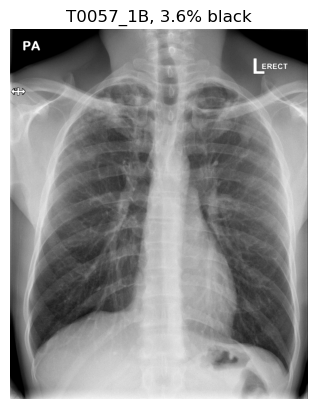

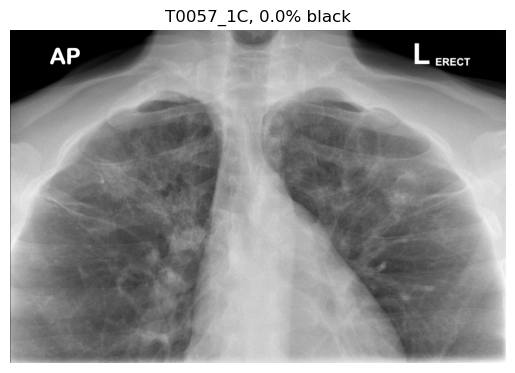

In [262]:
for i, row in df_CXR_pred.query("pid=='T0057'").iterrows():
    
    png_fName = row['png_Filename']
    perc_black = row['Percent_Black_Pixels']
    
    img = mpimg.imread(png_fName)
    
    plt.imshow(img, cmap='gray')
    plt.title(f"{os.path.basename(png_fName).split('.')[0]}, {np.round(perc_black, 1)}% black")
    plt.axis('off')
    plt.show()
    

In [134]:
# sns.scatterplot(data=df_CXR_pred.query("predicted_PLI_diff > 0").drop_duplicates(subset=['pid', 'Time']),
#                 x='Prop_Black_Pixels_diff',
#                 y='predicted_PLI_diff'
#                )

In [117]:
df_dicom_metadata.query("pid=='T0197'")

,file,SeriesInstanceUID,AcquisitionTime,InstanceNumber,PixelSpacing,ImageOrientation,Rows,Columns,RescaleIntercept,RescaleSlope,BaseName,pid,png_file
0,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,1.2.276.0.7230010.3.1.4.2528215671.2620.167584...,,1,"[0.148, 0.148]",,2529,2372,,,T0197_1B.dcm,T0197,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...
1,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,1.2.276.0.7230010.3.1.4.2528215671.3968.167584...,,1,"[0.148, 0.148]",,1458,2390,,,T0197_1C.dcm,T0197,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/p...


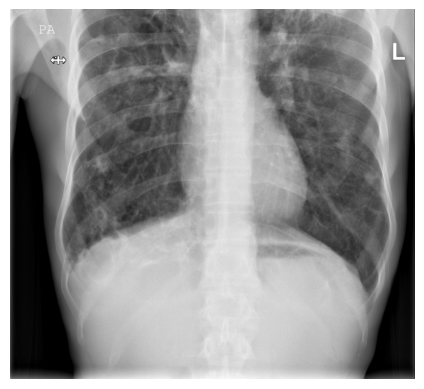

In [51]:
# Read the image
img = mpimg.imread(df.file.values[-1].replace('.dcm', '.png').replace('dicom', 'png'))

# Display it
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [11]:
df_CXR_pred.query("Time=='FU'").sort_values('predicted_PLI_diff')

,patientID_view,predicted_PLI,predicted_Timika,Filename,Status,pid,view,Time,predicted_PLI_diff,predicted_Timika_diff
324,T0161_2B,5.023587,7.843304,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0161,2B,FU,0.000000,0.000000
1067,T0374_2B,23.095991,27.322168,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0374,2B,FU,0.000000,0.000000
1072,T0375_2B,24.099537,29.711182,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0375,2B,FU,0.000000,0.000000
1076,T0376_2B,12.402187,13.776360,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0376,2B,FU,0.000000,0.000000
1080,T0377_2B,9.822505,13.822051,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0377,2B,FU,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
915,T0335_2B,9.748028,14.404529,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0335,2B,FU,6.531086,5.426163
963,T0348_2B,40.854070,52.664383,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0348,2B,FU,8.887070,17.173023
964,T0348_2C,31.967000,35.491360,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0348,2C,FU,8.887070,17.173023
603,T0242_2A,69.346750,74.880750,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/d...,Normal,T0242,2A,FU,32.769205,34.021093


# Checking that we have all CXRs that the BMC team has

Here are several spreadsheets. There is a list of PIDs for which we have CXR DICOMs and notes for each—particularly for TRUST—this notes whether the image is for the baseline visit, follow up visit, or an additional TB episode visit. It is more straightforward for TOTAL and the supplement since we only had images for one timepoint. The other two spreadsheets detail the names and locations of each image so you can quickly reference.


Would you be able to follow up with PLI for the list of PIDs that Karen mentioned below? It looks like the only TRUST PID that you do not have access to is T0110, I cannot find it in our files either and think the field team may not have uploaded it. I will continue looking. Can you or Kristin also send us for the TOTAL images?

In [146]:
# df_CXR_pids = pd.read_excel("~/TRUST_data_processing/raw_data/CXR PIDs.xlsx", sheet_name=None)
df_TOTAL_CXR = pd.read_excel("~/TRUST_data_processing/raw_data/TOTAL_CXR_Images_tracking.xlsx", sheet_name=None)
df_TRUST_CXR = pd.read_excel("~/TRUST_data_processing/raw_data/TRUST_CXR_Images_tracking.xlsx", sheet_name=None)

# if len(df_CXR_pids) == 1:
#     df_CXR_pids = df_CXR_pids[list(df_CXR_pids.keys())[0]]
    
if len(df_TOTAL_CXR) == 1:
    df_TOTAL_CXR = df_TOTAL_CXR[list(df_TOTAL_CXR.keys())[0]]
    
if len(df_TRUST_CXR) == 1:
    df_TRUST_CXR = df_TRUST_CXR[list(df_TRUST_CXR.keys())[0]]

In [155]:
df_TRUST_CXR.iloc[df_TRUST_CXR.index.values[df_TRUST_CXR.duplicated(subset='Name', keep=False)]].dropna(subset='Name').sort_values('Name').Path.values

array(['teams/TRUSTResearchTeam/Shared Documents/General/TRUST/DICOM Chest X-Ray Images/Round 1_Transferred to NIH 5.1.23',
       'teams/TRUSTResearchTeam/Shared Documents/General/TRUST/DICOM Chest X-Ray Images/Round 4_Transferred to NIH_04.11.2025',
       'teams/TRUSTResearchTeam/Shared Documents/General/TRUST/DICOM Chest X-Ray Images/Round 4_Transferred to NIH_04.11.2025',
       ...,
       'teams/TRUSTResearchTeam/Shared Documents/General/TRUST/DICOM Chest X-Ray Images/Round 2_Transferred to NIH_07.19.2024/2024',
       'teams/TRUSTResearchTeam/Shared Documents/General/TRUST/DICOM Chest X-Ray Images/Round 2_Transferred to NIH_07.19.2024/2024',
       'teams/TRUSTResearchTeam/Shared Documents/General/TRUST/DICOM Chest X-Ray Images/Round 4_Transferred to NIH_04.11.2025'],
      dtype=object)

In [165]:
df_TRUST_CXR.shape, df_TRUST_CXR.drop_duplicates(subset=['Name', 'notes', 'Path']).shape

((2011, 12), (1999, 12))

In [162]:
df_TRUST_CXR.iloc[df_TRUST_CXR.index.values[df_TRUST_CXR.duplicated(subset=['Name', 'notes'], keep=False)]].dropna(subset='Name').sort_values('Name')

,pid,redcap_repeat_instance,Name,Modified,Modified By,Item Type,Path,redcap_event_name,redcap_repeat_instrument,cxr_dicom_add,notes,in_redcap
264,T0131,1.0,T0131_1A.dcm,45379.490602,"Thomson, Sarah",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0
265,T0131,1.0,T0131_1A.dcm,45754.504039,"Quintero, Renzo",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0
262,T0131,1.0,T0131_1B.dcm,45754.504306,"Quintero, Renzo",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0
263,T0131,1.0,T0131_1B.dcm,45379.498958,"Thomson, Sarah",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0
329,T0161,2.0,T0161_2A.dcm,45379.498924,"Thomson, Sarah",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,follow up,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1990,T0474,2.0,T0474_2B.dcm,45754.518310,"Quintero, Renzo",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,follow up,1.0
2001,T0476,1.0,T0476_1A.dcm,45754.538021,"Quintero, Renzo",Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0
1998,T0476,1.0,T0476_1A.dcm,45450.429606,Rebecca E. Hoffman,Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0
1999,T0476,1.0,T0476_1B.dcm,45450.429699,Rebecca E. Hoffman,Item,teams/TRUSTResearchTeam/Shared Documents/Gener...,chest_radiograph_arm_1,chest_radiograph,1.0,baseline,1.0


In [147]:
TRUST_CXR_dir = "/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR/dicom"

TOTAL_CXR_dir = "/n/data1/hms/dbmi/farhat/rollingDB/TOTAL/CXR/dicom"

TRUST_CXR_fNames = os.listdir(TRUST_CXR_dir)
TOTAL_CXR_fNames = os.listdir(TOTAL_CXR_dir)

TRUST_CXR_fNames = pd.DataFrame(TRUST_CXR_fNames, columns=['fName'])
TRUST_CXR_fNames['pid'] = TRUST_CXR_fNames['fName'].str.split('_').str[0]
TRUST_CXR_fNames['view'] = TRUST_CXR_fNames['fName'].str.split('_', n=1).str[-1].str.replace('.dcm', '')

TOTAL_CXR_fNames = pd.DataFrame(TOTAL_CXR_fNames, columns=['fName'])
TOTAL_CXR_fNames['pid'] = TOTAL_CXR_fNames['fName'].str.split('_').str[0]
TOTAL_CXR_fNames['view'] = TOTAL_CXR_fNames['fName'].str.split('_', n=1).str[-1].str.replace('.dcm', '')

len(TRUST_CXR_fNames), len(TOTAL_CXR_fNames)

(1469, 457)

In [148]:
TOTAL_missing_dicoms = df_TOTAL_CXR.loc[~pd.isnull(df_TOTAL_CXR['Name'])].query("Name not in @TOTAL_CXR_fNames.fName")
len(TOTAL_missing_dicoms)

0

In [149]:
df_TRUST_CXR.loc[~pd.isnull(df_TRUST_CXR['Name'])].query("Name not in @TRUST_CXR_fNames.fName").Name.values

array(['T0262 Pneumothorax Report Additonal 2024-11-25 .dcm',
       'T0384 CXR Pneumothorax Report 2025-02-04.dcm',
       'T0386 CXR Pneumothorax Report Additional 2 2024-10-23.dcm',
       'T0457 CXR Pneumothorax Report PM6 2024-12-03.dcm',
       'T0458 CXR Pneumothorax Report 2024-12-10.dcm',
       'T0459 CXR Pneumothorax Report PM6 2024-11-25.dcm',
       'T0462 CXR Pneumothorax Report Additional 2025-01-14.dcm',
       'T0465 Pneumothorax Report PM6 2025-01-21.dcm',
       'T0466 PNEUMOTORAX REPORT PM6 2025-01-21.dcm',
       'T0474 CXR Pneumothorax Report PM6 2025-02-12.dcm',
       'TRUST_T0244_Additional CXR_ PA_28072025.dcm',
       'TRUST_T0244_Additional CXR_LA_28072025.dcm',
       'TRUST_T0477_Post 2_CXR_LA_28072025.dcm',
       'TRUST_T0477_Post 2_CXR_PA_28072025.dcm'], dtype=object)

In [150]:
search_paths = df_TRUST_CXR.loc[~pd.isnull(df_TRUST_CXR['Name'])].query("Name not in @TRUST_CXR_fNames.fName").Path.unique()
len(search_paths)

2

In [102]:
for path in search_paths:
        
    pids = df_TRUST_CXR.loc[~pd.isnull(df_TRUST_CXR['Name'])].query("Name not in @TRUST_CXR_fNames.fName & ~Name.str.contains('pneumot', case=False) & ~Name.str.contains('Additional')").query("Path==@path")
    
    if len(pids) > 0:
        print(path)
    
    for fName in pids.Name.values:
        print(f"    {fName}")

teams/TRUSTResearchTeam/Shared Documents/General/TRUST/DICOM Chest X-Ray Images
    TRUST_T0477_Post 2_CXR_LA_28072025.dcm
    TRUST_T0477_Post 2_CXR_PA_28072025.dcm


# Get Predictions and Annotate

In [199]:
def combine_annotate_CXR_predictions(pred_dir):

    pli_pred = pd.read_csv(f"{pred_dir}/pli_regression_predictions.csv").rename(columns={'predicted_label': 'predicted_PLI'})
    timika_pred = pd.read_csv(f"{pred_dir}/timika_regression_predictions.csv").rename(columns={'predicted_label': 'predicted_Timika'})
    outlier_annot = pd.read_csv(f"{pred_dir}/outlier_detection_results_all_dicoms.csv")

    outlier_annot['patientID_view'] = [os.path.basename(fName).split('.')[0] for fName in outlier_annot.Filename.values]

    df_pred = outlier_annot.merge(pli_pred, on='patientID_view').merge(timika_pred)
    print(f"{len(df_pred)} CXR files")

    df_pred['Name'] = [os.path.basename(fName) for fName in df_pred['Filename'].values]

    df_pred[['pid', 'view', 'replicate']] = df_pred['patientID_view'].str.split('_', expand=True)
    
    # df_pred = df_pred.query("Status=='Normal'").reset_index(drop=True)
    print(f"{df_pred.pid.nunique()} pids")

    df_pred.loc[df_pred['view'].str.startswith('1'), 'Sample'] = 'BL'
    df_pred.loc[~df_pred['view'].str.startswith('1'), 'Sample'] = 'FU'

    return df_pred

In [200]:
TRUST_search_pids = ["T0110", "T0386", "T0475"]

TOTAL_search_pids = ["P0024", "P0048", "P0055", "P0251", "P0359", "P0522", "P0531", "P0709", "P0736", "P0740"]

In [201]:
pred_dir = "/n/data1/hms/dbmi/farhat/rollingDB/TOTAL/CXR"

df_TOTAL_pred = combine_annotate_CXR_predictions(pred_dir)

456 CXR files
218 pids


In [202]:
pids_BL_FU_CXRs = pd.DataFrame(df_TOTAL_pred.groupby('pid').Sample.nunique()).query("Sample > 1").index.values
print(f"{len(pids_BL_FU_CXRs)} pids have baseline and follow-up CXRs")

0 pids have baseline and follow-up CXRs


In [193]:
df_TOTAL_CXR.loc[pd.isnull(df_TOTAL_CXR['Name'])].query("pid in @TOTAL_search_pids")

,pid,Name,Modified,Modified By,Item Type,Path,redcap_repeat_instance,cxr_date,in_redcap
119,P0024,NaN,NaT,NaN,NaN,NaN,NaN,2021-07-16,1.0
120,P0048,NaN,NaT,NaN,NaN,NaN,NaN,2021-07-23,1.0
185,P0359,NaN,NaT,NaN,NaN,NaN,NaN,2022-08-04,1.0
242,P0709,NaN,NaT,NaN,NaN,NaN,NaN,2023-07-20,1.0


In [194]:
pred_dir = "/n/data1/hms/dbmi/farhat/rollingDB/TRUST/CXR"

df_TRUST_pred = combine_annotate_CXR_predictions(pred_dir)

1468 CXR files
434 pids


In [195]:
pids_BL_FU_CXRs = pd.DataFrame(df_TRUST_pred.groupby('pid').Sample.nunique()).query("Sample > 1").index.values
print(f"{len(pids_BL_FU_CXRs)} pids have baseline and follow-up CXRs")

199 pids have baseline and follow-up CXRs


In [217]:
pd.concat([df_TOTAL_pred.query("pid in @TOTAL_search_pids"), df_TRUST_pred.query("pid in @TRUST_search_pids")])[['pid', 'Status', 'Filename', 'Name', 'patientID_view', 'predicted_PLI']].to_csv("./processed_data/20251030_PLIpred_3pids.csv", index=False)

In [197]:
# df_pred.to_csv("./processed_data/20250817_CXR_predictions.csv", index=False)

In [ ]:
# dicom_files = glob.glob("/n/data1/hms/dbmi/farhat/Sanjana/TRUST_CXR/*/dicom/*.dcm")
dicom_files = glob.glob("/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dicom/*.dcm") + glob.glob("/n/data1/hms/dbmi/farhat/Sanjana/CXR/TRUST/dicom/*.dcm")
len(dicom_files)

1871

In [ ]:
TRUST_dicoms = glob.glob("/n/data1/hms/dbmi/farhat/Sanjana/CXR/TRUST/dicom/*.dcm")
len(TRUST_dicoms)

1437

In [ ]:
pids = [os.path.basename(fName).split('_')[0] for fName in TRUST_dicoms]
len(pids), len(np.unique(pids))

(1437, 455)

In [9]:
dicom_files_no_dirs = [os.path.basename(fName).split('.')[0] for fName in dicom_files]
len(dicom_files_no_dirs), len(np.unique(dicom_files_no_dirs))

(1871, 1871)

In [10]:
df_dicoms = pd.DataFrame({'fName': dicom_files})

df_dicoms['file'] = [os.path.basename(fName).split('.')[0] for fName in df_dicoms.fName]
df_dicoms[['pid', 'Suffix', 'Replicate']] = df_dicoms['file'].str.split('_', expand=True)

df_dicoms['Study'] = ['TRUST' if pid.startswith('T') else 'TOTAL' for pid in df_dicoms['pid']]

In [11]:
# df_dicoms.iloc[df_dicoms.index.values[df_dicoms.duplicated(subset=['pid', 'Suffix'], keep=False)]].sort_values('file').fName.values

In [12]:
for name in df_dicoms.iloc[df_dicoms.index.values[df_dicoms.duplicated(subset=['pid', 'Suffix'], keep=False)]].sort_values('file').file.unique():
    print(name)

A0003_1A
A0003_1A_1
A0004_1A
A0004_1A_2
A0008_1B
A0008_1B_2
CT0048_1A_1
CT0048_1A_2
H0050_1A_1
H0050_1A_2
H0053_1B_1
H0053_1B_2
H0056_1B
H0056_1B_2
J0004_1A_1
J0004_1A_2
J0004_1B
J0004_1B_2
P0560_1A_1
P0560_1A_2
P0695_1B_1
P0695_1B_2
T0025_1B
T0025_1B_2
T0032_1B
T0032_1B_2
T0268_2A
T0268_2A_2
T0268_2B
T0268_2B_2
T0292_2A
T0292_2A_2
T0292_2B
T0292_2B_2
T0364_2A
T0364_2A_2
T0379_2B
T0379_2B_2
T0458_1B
T0458_1B_2


In [13]:
df_dicoms.iloc[df_dicoms.index.values[df_dicoms.duplicated(subset=['pid', 'Suffix'], keep=False)]].sort_values('file')

,fName,file,pid,Suffix,Replicate,Study
4,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,A0003_1A,A0003,1A,None,TOTAL
5,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,A0003_1A_1,A0003,1A,1,TOTAL
7,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,A0004_1A,A0004,1A,None,TOTAL
8,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,A0004_1A_2,A0004,1A,2,TOTAL
17,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,A0008_1B,A0008,1B,None,TOTAL
18,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,A0008_1B_2,A0008,1B,2,TOTAL
88,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,CT0048_1A_1,CT0048,1A,1,TOTAL
89,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,CT0048_1A_2,CT0048,1A,2,TOTAL
194,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,H0050_1A_1,H0050,1A,1,TOTAL
195,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,H0050_1A_2,H0050,1A,2,TOTAL


### From Nina Cesare, August 4, 2025

Baseline, LAT = 1A   

Baseline, PA = 1B   

Baseline, AP = 1C  

Follow-up visit, LAT = 2A  

Follow-up visit, PA = 2B  

Follow-up visit, AP = 2C  

In [14]:
df_dicoms = df_dicoms.dropna(subset='Suffix').reset_index(drop=True)

df_dicoms.loc[df_dicoms['Suffix'].str.startswith('1'), 'Sample'] = 'BL'
df_dicoms.loc[df_dicoms['Suffix'].str.startswith('2'), 'Sample'] = 'FU'

df_dicoms.loc[df_dicoms['Suffix'].str.endswith('A'), 'View'] = 'LAT'
df_dicoms.loc[df_dicoms['Suffix'].str.endswith('B'), 'View'] = 'PA'
df_dicoms.loc[df_dicoms['Suffix'].str.endswith('C'), 'View'] = 'AP'

## Duplicates

In [15]:
df_duplicates = df_dicoms.iloc[df_dicoms.index.values[df_dicoms.duplicated(subset=['pid', 'Suffix'], keep=False)]].sort_values(['pid', 'Suffix']).reset_index(drop=True)
len(df_duplicates)

40

In [17]:
dup_pairs = []

for pid in df_duplicates.pid.unique():
    
    for suffix in df_duplicates.query("pid==@pid").Suffix.unique():
        
        # all the files with the same pid and suffix
        fNames = list(df_duplicates.query("pid==@pid & Suffix==@suffix").fName.values)
        
        if len(fNames) == 2:
            dup_pairs.append(fNames)
        else:
            # get all combinations
            fName_pairs = list(itertools.combinations(df_duplicates.query("pid==@pid & Suffix==@suffix").fName, 2))
            
            for pair in fName_pairs:
                dup_pairs.append(list(pair))
                
len(dup_pairs)

20

In [22]:
# df_check_duplicates = pd.DataFrame(dup_pairs, columns = ['fName1', 'fName2'])
# df_check_duplicates[['fName1', 'fName2']] = df_check_duplicates[['fName1', 'fName2']].astype(str)
# df_check_duplicates.to_csv("./DICOMs_check_duplicates.csv", index=False)

In [26]:
df_check_duplicates = pd.read_csv("./DICOMs_check_duplicates.csv")
print(len(df_check_duplicates))

20


In [27]:
df_check_duplicates

,fName1,fName2,SameHeader,SamePixels
0,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,0.0,0.0
1,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,0.0,0.0
2,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,0.0,0.0
3,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,0.0,0.0
4,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,0.0,0.0
5,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,0.0,0.0
6,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,0.0,0.0
7,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,0.0,0.0
8,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,0.0,0.0
9,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,/n/data1/hms/dbmi/farhat/Sanjana/CXR/TOTAL/dic...,0.0,0.0


In [246]:
# to_delete = []

# for i, row in df_check_duplicates.query("SameHeader == 1 & SamePixels == 1").iterrows():
    
#     if 'test_set' in row['fName1']:
#         to_delete.append(row['fName1'])
        
#     if 'test_set' in row['fName2']:
#         to_delete.append(row['fName2'])
        
# to_delete = np.unique(to_delete)
# len(to_delete)

# for fName in to_delete:
#     os.remove(fName)

In [139]:
df_check_duplicates.query("SameHeader == 1 & SamePixels == 1 & fName1 not in @to_delete & fName2 not in @to_delete").fName1.values

array(['/n/data1/hms/dbmi/farhat/Sanjana/TRUST_CXR/TOTAL/dicom/P0453_1A_1.dcm',
       '/n/data1/hms/dbmi/farhat/Sanjana/TRUST_CXR/20250417_images/dicom/T0309_2B.dcm'],
      dtype=object)

In [140]:
df_check_duplicates.query("SameHeader == 1 & SamePixels == 1 & fName1 not in @to_delete & fName2 not in @to_delete").fName2.values

array(['/n/data1/hms/dbmi/farhat/Sanjana/TRUST_CXR/TOTAL/dicom/P0453_1A_2.dcm',
       '/n/data1/hms/dbmi/farhat/Sanjana/TRUST_CXR/20250417_images/dicom/T0309_2B_2.dcm'],
      dtype=object)